# 03b - Random Matrix Benchmark: Failure of the Five Stylized Facts

This notebook complements `03_base_corr_matrix_analysis.ipynb` by building the **Random Matrix Theory (RMT) benchmark** discussed in Section 3.7 of the thesis (`sec:benchmark_rmt`, "*Benchmark test: fallimento strutturale della Random Matrix Theory*").

We generate a purely random correlation matrix from `N = 362` i.i.d. white-noise Gaussian time series of length `T = 724` days — matching exactly the `(N, T)` of the empirical reference matrix #100 analyzed in notebook 03 — and subject it to the **same five-property protocol** used for the real market matrix. Because `N` and `T` are identical in both cases, any visual/statistical discrepancy between the "Real" and "Random" panels below is attributable exclusively to genuine market structure, not to a difference in sample size or dimensionality.

For each of the five stylized facts we produce a **side-by-side comparison figure** (Mercato Reale | Benchmark RMT), saved to `../tesi/Pictures/capitolo3/` with the suffix `_rmt_comparison`, ready to be embedded in Section 3.7 of the thesis.


In [1]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings

warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')
torch.set_printoptions(linewidth=200, precision=4, sci_mode=False)

# ----- Reproducibility -----
SEED = 42
rng = np.random.default_rng(SEED)

# ----- Match the empirical matrix #100 used in notebook 03 -----
FILE_NAME = 'data_00_20'
WINDOW_LENGTH = 724      # T: number of daily return observations per window
STRIDE = 10
SELECTED_CORR_MATRIX = 100
NUM_ASSETS = 362         # N: number of assets

q = NUM_ASSETS / WINDOW_LENGTH
print(f"Random matrix benchmark setup: N={NUM_ASSETS} assets, T={WINDOW_LENGTH} days")
print(f"q = N/T = {NUM_ASSETS}/{WINDOW_LENGTH} = {q:.4f}")
print(f"Random seed: {SEED}")


Random matrix benchmark setup: N=362 assets, T=724 days
q = N/T = 362/724 = 0.5000
Random seed: 42


## Section 1: Load the Empirical Reference Matrix (#100) and Build the Random Benchmark Matrix

We load the same empirical correlation matrix (index 100, `N=362`, `W=724`) analyzed in notebook 03, and construct the random control matrix by:

1. Sampling `X ∈ R^{N×T}` i.i.d. from `N(0, 1)` (pure white noise — no autocorrelation, no cross-sectional dependence);
2. Computing the sample Pearson correlation matrix `C_random = corr(X)`.

This is exactly the null-hypothesis construction described in Section 3.7: *"estrazione di N serie temporali di puro rumore gaussiano bianco i.i.d."*


In [2]:
# ===== Load empirical correlation matrices tensor =====
TENSOR_PATH = Path(f'../data/processed/{FILE_NAME}/correlation_matrices/{FILE_NAME}_w{WINDOW_LENGTH}_s{STRIDE}.pt')
checkpoint = torch.load(TENSOR_PATH, weights_only=False)

corr_tensor = checkpoint['corr_tensor']
tickers = checkpoint['tickers']

assert corr_tensor.shape[1] == NUM_ASSETS, "NUM_ASSETS must match the tensor's asset dimension"


def sanitize_correlation_matrix(corr_matrix):
    corr_matrix = np.clip(corr_matrix, -1.0, 1.0)
    corr_matrix = (corr_matrix + corr_matrix.T) / 2.0
    np.fill_diagonal(corr_matrix, 1.0)
    return corr_matrix


def build_distance_matrix(corr_matrix):
    dist_matrix = np.sqrt(np.maximum(0.0, 2.0 * (1.0 - corr_matrix)))
    dist_matrix = (dist_matrix + dist_matrix.T) / 2.0
    np.fill_diagonal(dist_matrix, 0.0)
    return dist_matrix


# ----- Real reference matrix (#100) -----
real_corr = corr_tensor[SELECTED_CORR_MATRIX]
if hasattr(real_corr, 'cpu'):
    real_corr = real_corr.cpu().numpy()
real_corr = sanitize_correlation_matrix(np.array(real_corr, dtype=float))

# ----- Random benchmark matrix: N i.i.d. Gaussian white-noise series of length T -----
X_random = rng.standard_normal(size=(NUM_ASSETS, WINDOW_LENGTH))
random_corr = np.corrcoef(X_random)
random_corr = sanitize_correlation_matrix(random_corr)

print(f"Real matrix #{SELECTED_CORR_MATRIX} shape: {real_corr.shape}")
print(f"Random matrix shape: {random_corr.shape} (built from {NUM_ASSETS} iid N(0,1) series of length {WINDOW_LENGTH}, seed={SEED})")


Real matrix #100 shape: (362, 362)
Random matrix shape: (362, 362) (built from 362 iid N(0,1) series of length 724, seed=42)


In [3]:
# ===== VALIDITY CHECK: both matrices must be proper correlation matrices in [-1, 1] =====
# random_corr is built via np.corrcoef (Pearson correlation), which is mathematically
# guaranteed to lie in [-1, 1] with a unit diagonal -- it is NOT an arbitrary random
# matrix with unconstrained entries. sanitize_correlation_matrix() additionally clips
# any floating-point overshoot (e.g. 1.0000000002 on the diagonal) for numerical safety.
for name, mat in [('real_corr', real_corr), ('random_corr', random_corr)]:
    assert mat.min() >= -1.0 - 1e-9, f"{name} has values below -1: min={mat.min()}"
    assert mat.max() <= 1.0 + 1e-9, f"{name} has values above 1: max={mat.max()}"
    assert np.allclose(np.diag(mat), 1.0), f"{name} diagonal is not 1.0"
    assert np.allclose(mat, mat.T), f"{name} is not symmetric"
    print(f"{name:12s} -> min={mat.min():.6f}, max={mat.max():.6f}, diag=1.0, symmetric=True")

print("\nAll correlation matrices are valid: values in [-1, 1], unit diagonal, symmetric.")


real_corr    -> min=-0.098512, max=1.000000, diag=1.0, symmetric=True
random_corr  -> min=-0.163215, max=1.000000, diag=1.0, symmetric=True

All correlation matrices are valid: values in [-1, 1], unit diagonal, symmetric.


In [4]:
# ===== SET UP RESULTS / FIGURES FOLDERS =====
RESULTS_FOLDER = Path('../results') / f'{FILE_NAME}_w{WINDOW_LENGTH}_s{STRIDE}' / 'random_matrix_benchmark'
RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)

FIGURES_FOLDER = Path('../tesi/Pictures/capitolo3')
FIGURES_FOLDER.mkdir(parents=True, exist_ok=True)

print(f"Diagnostics saved to: {RESULTS_FOLDER.resolve()}")
print(f"Thesis figures saved to: {FIGURES_FOLDER.resolve()}")


Diagnostics saved to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\results\data_00_20_w724_s10\random_matrix_benchmark
Thesis figures saved to: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\tesi\Pictures\capitolo3


## Section 2: Property 1 - Distribution of Pairwise Correlations

**Real markets:** the distribution of off-diagonal coefficients $C_{ij}$ is markedly asymmetric and shifted towards positive values (mean typically in $[0.2, 0.5]$), reflecting the systematic "market effect".

**Pure-noise benchmark:** under the null hypothesis of independent series, the sampling distribution of the Pearson correlation coefficient is symmetric around zero, with standard deviation $\approx 1/\sqrt{T}$.


--- Statistiche Pairwise ---
REALE   -> media: 0.2334, mediana: 0.2257, std: 0.0918, % negativi: 0.06%
RANDOM  -> media: 0.0000, mediana: 0.0000, std: 0.0373, % negativi: 49.95%
Std teorica attesa per benchmark RMT (1/sqrt(T)): 0.0372


Saved: ..\tesi\Pictures\capitolo3\fig_pairwise_distribution_rmt_comparison.png


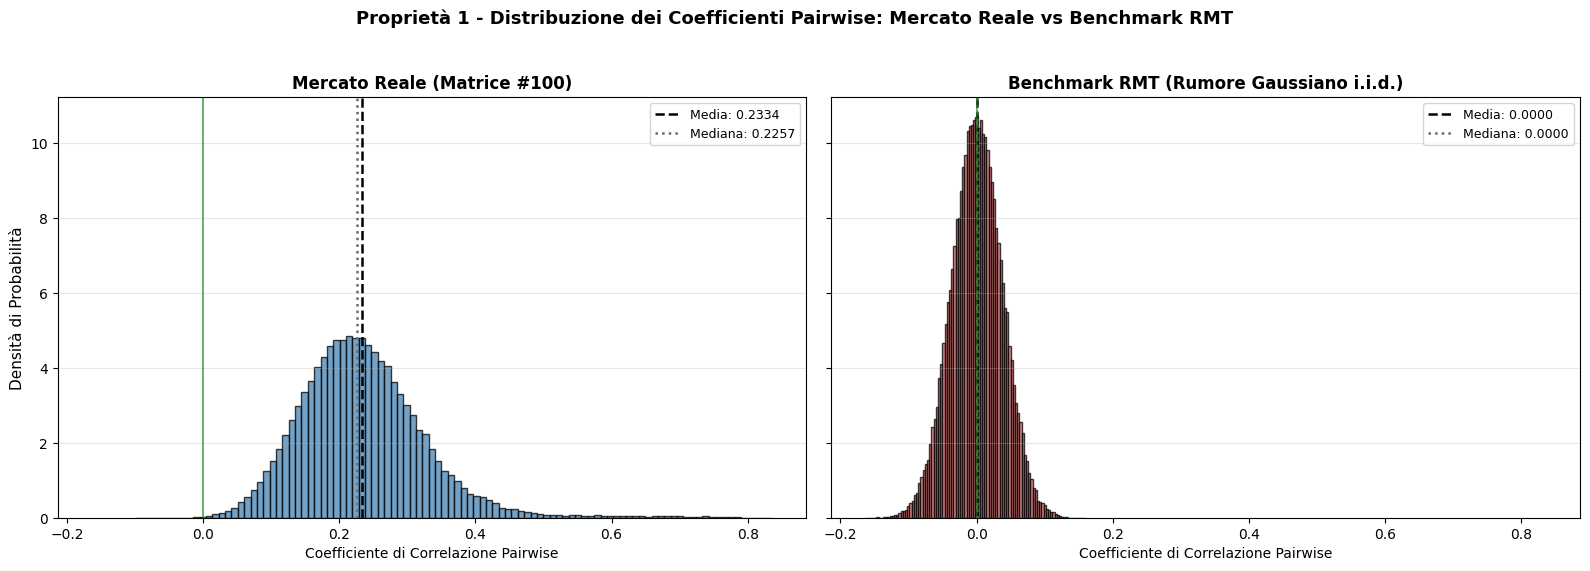

In [5]:
triu_idx = np.triu_indices(NUM_ASSETS, k=1)
real_values = real_corr[triu_idx]
random_values = random_corr[triu_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharex=True, sharey=True)

panels = [
    (axes[0], real_values, f'Mercato Reale (Matrice #{SELECTED_CORR_MATRIX})', 'steelblue'),
    (axes[1], random_values, 'Benchmark RMT (Rumore Gaussiano i.i.d.)', 'indianred'),
]

for ax, values, title, color in panels:
    mean_v, median_v = np.mean(values), np.median(values)
    ax.hist(values, bins=100, color=color, edgecolor='black', alpha=0.75, density=True)
    ax.axvline(mean_v, color='black', linestyle='--', linewidth=1.8, label=f'Media: {mean_v:.4f}')
    ax.axvline(median_v, color='dimgray', linestyle=':', linewidth=1.8, label=f'Mediana: {median_v:.4f}')
    ax.axvline(0, color='green', linewidth=1.2, alpha=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficiente di Correlazione Pairwise', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Densità di Probabilità', fontsize=11)
fig.suptitle('Proprietà 1 - Distribuzione dei Coefficienti Pairwise: Mercato Reale vs Benchmark RMT',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()

theoretical_std = 1.0 / np.sqrt(WINDOW_LENGTH)
print("--- Statistiche Pairwise ---")
print(f"REALE   -> media: {np.mean(real_values):.4f}, mediana: {np.median(real_values):.4f}, "
      f"std: {np.std(real_values):.4f}, % negativi: {100*np.mean(real_values < 0):.2f}%")
print(f"RANDOM  -> media: {np.mean(random_values):.4f}, mediana: {np.median(random_values):.4f}, "
      f"std: {np.std(random_values):.4f}, % negativi: {100*np.mean(random_values < 0):.2f}%")
print(f"Std teorica attesa per benchmark RMT (1/sqrt(T)): {theoretical_std:.4f}")

out_path = FIGURES_FOLDER / 'fig_pairwise_distribution_rmt_comparison.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()


## Section 3: Property 2 - Eigenvalue Spectrum vs Marchenko-Pastur

**Real markets:** the spectrum splits into a dominant market mode ($\lambda_1 \gg \lambda_+$), a handful of sector modes ($\lambda_k > \lambda_+$), and a bulk consistent with pure noise.

**Pure-noise benchmark:** under $N \to \infty, T \to \infty$ with $q = N/T$ fixed, the whole spectrum converges to the Marchenko-Pastur density with no eigenvalue systematically escaping $[\lambda_-, \lambda_+]$ (finite-size fluctuations can still push the single largest eigenvalue marginally above $\lambda_+$ - this is expected and is *not* a market mode).


q = N/T = 362/724 = 0.5000
Limiti teorici MP: lambda- = 0.0858, lambda+ = 2.9142

REALE  -> lambda_1 = 88.7529 (24.52% varianza totale), autovalori oltre lambda+: 9
RANDOM -> lambda_1 = 2.9071 (0.80% varianza totale), autovalori oltre lambda+: 0
Rapporto lambda_1 (reale / random): 30.5x


Saved: ..\tesi\Pictures\capitolo3\fig_marchenko_pastur_rmt_comparison.png


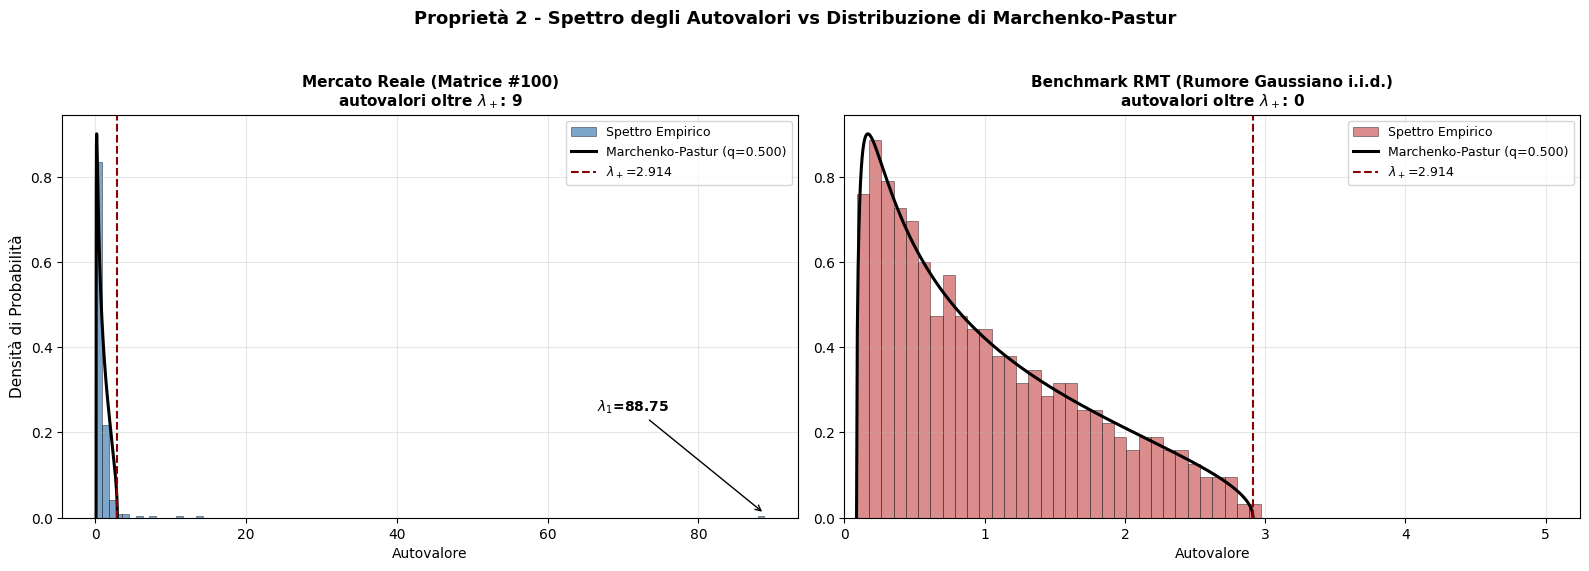

In [6]:
def marchenko_pastur_pdf(x, lmbd, sigma=1.0):
    b = (sigma * (1 + np.sqrt(lmbd))) ** 2
    a = (sigma * (1 - np.sqrt(lmbd))) ** 2
    result = np.zeros_like(x, dtype=float)
    mask = (x >= a) & (x <= b)
    result[mask] = (1 / (2 * np.pi * sigma * sigma * x[mask] * lmbd)) * np.sqrt((b - x[mask]) * (x[mask] - a))
    return result


lambda_minus = (1 - np.sqrt(q)) ** 2
lambda_plus = (1 + np.sqrt(q)) ** 2

evals_real = np.clip(np.linalg.eigvalsh(real_corr)[::-1], 0, None)
evals_random = np.clip(np.linalg.eigvalsh(random_corr)[::-1], 0, None)

n_above_real = int(np.sum(evals_real > lambda_plus))
n_above_random = int(np.sum(evals_random > lambda_plus))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# ----- Real panel: full range (dominant eigenvalue lies far outside the bulk) -----
ax = axes[0]
ax.hist(evals_real, bins=100, density=True, alpha=0.7, color='steelblue',
        edgecolor='black', linewidth=0.4, label='Spettro Empirico')
x_theory = np.linspace(lambda_minus, lambda_plus, 500)
y_theory = marchenko_pastur_pdf(x_theory, q)
ax.plot(x_theory, y_theory, 'k-', linewidth=2.2, label=f'Marchenko-Pastur (q={q:.3f})')
ax.axvline(lambda_plus, color='darkred', linestyle='--', linewidth=1.5, label=f'$\\lambda_+$={lambda_plus:.3f}')
ax.annotate(f'$\\lambda_1$={evals_real[0]:.2f}', xy=(evals_real[0], 0.01), xytext=(evals_real[0]*0.75, 0.25),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10, fontweight='bold')
ax.set_title(f'Mercato Reale (Matrice #{SELECTED_CORR_MATRIX})\nautovalori oltre $\\lambda_+$: {n_above_real}',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Autovalore', fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ----- Random panel: zoom on the bulk (no dominant mode to show) -----
ax = axes[1]
zoom_max = max(lambda_plus * 1.8, evals_random[0] * 1.15)
ax.hist(evals_random, bins=60, range=(0, zoom_max), density=True, alpha=0.7, color='indianred',
        edgecolor='black', linewidth=0.4, label='Spettro Empirico')
ax.plot(x_theory, y_theory, 'k-', linewidth=2.2, label=f'Marchenko-Pastur (q={q:.3f})')
ax.axvline(lambda_plus, color='darkred', linestyle='--', linewidth=1.5, label=f'$\\lambda_+$={lambda_plus:.3f}')
ax.set_title(f'Benchmark RMT (Rumore Gaussiano i.i.d.)\nautovalori oltre $\\lambda_+$: {n_above_random}',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Autovalore', fontsize=10)
ax.set_xlim(0, zoom_max)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

axes[0].set_ylabel('Densità di Probabilità', fontsize=11)
fig.suptitle('Proprietà 2 - Spettro degli Autovalori vs Distribuzione di Marchenko-Pastur',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()

print(f"q = N/T = {NUM_ASSETS}/{WINDOW_LENGTH} = {q:.4f}")
print(f"Limiti teorici MP: lambda- = {lambda_minus:.4f}, lambda+ = {lambda_plus:.4f}")
print()
print(f"REALE  -> lambda_1 = {evals_real[0]:.4f} ({100*evals_real[0]/NUM_ASSETS:.2f}% varianza totale), "
      f"autovalori oltre lambda+: {n_above_real}")
print(f"RANDOM -> lambda_1 = {evals_random[0]:.4f} ({100*evals_random[0]/NUM_ASSETS:.2f}% varianza totale), "
      f"autovalori oltre lambda+: {n_above_random}")
print(f"Rapporto lambda_1 (reale / random): {evals_real[0]/evals_random[0]:.1f}x")

out_path = FIGURES_FOLDER / 'fig_marchenko_pastur_rmt_comparison.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()


## Section 4: Property 3 - Perron-Frobenius Property

**Real markets:** despite the presence of pairwise negative correlations, the dominant eigenvector $\mathbf{v}_1$ has components that are *all of the same sign* (the "market mode" acts cooperatively on every asset).

**Pure-noise benchmark:** with no systematic co-movement, the leading eigenvector of a random correlation matrix has components with **randomly mixed signs** - the Perron-Frobenius property fails.


--- Proprietà di Perron-Frobenius ---
REALE  -> tutte le componenti stesso segno: True (molteplicità lambda_1: 1)
RANDOM -> tutte le componenti stesso segno: False (50.83% componenti negative, 49.17% positive)


Saved: ..\tesi\Pictures\capitolo3\fig_perron_frobenius_rmt_comparison.png


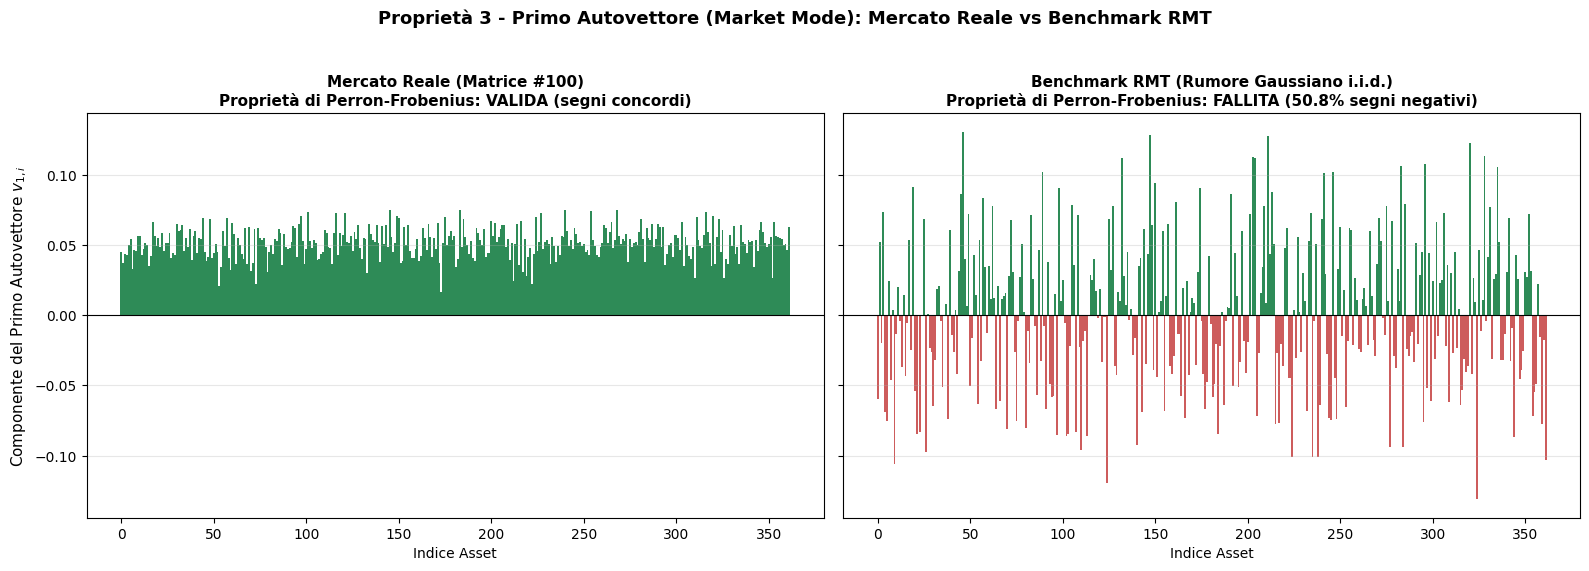

In [7]:
def leading_eigenvector(corr_matrix):
    evals, evecs = np.linalg.eigh(corr_matrix)
    evals = evals[::-1]
    evecs = evecs[:, ::-1]
    v1 = evecs[:, 0].copy()
    if np.sum(v1) < 0:
        v1 = -v1
    return evals, v1


evals_real2, v1_real = leading_eigenvector(real_corr)
evals_random2, v1_random = leading_eigenvector(random_corr)

pf_holds_real = bool(np.all(v1_real >= -1e-8))
pf_holds_random = bool(np.all(v1_random >= -1e-8))
frac_neg_real = 100 * np.mean(v1_real < 0)
frac_neg_random = 100 * np.mean(v1_random < 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
asset_idx = np.arange(NUM_ASSETS)

panels = [
    (axes[0], v1_real, f'Mercato Reale (Matrice #{SELECTED_CORR_MATRIX})', pf_holds_real, frac_neg_real),
    (axes[1], v1_random, 'Benchmark RMT (Rumore Gaussiano i.i.d.)', pf_holds_random, frac_neg_random),
]

for ax, v1, title, pf_holds, frac_neg in panels:
    colors = np.where(v1 >= 0, 'seagreen', 'indianred')
    ax.bar(asset_idx, v1, color=colors, width=1.0, edgecolor='none')
    ax.axhline(0, color='black', linewidth=0.8)
    verdict = 'VALIDA (segni concordi)' if pf_holds else f'FALLITA ({frac_neg:.1f}% segni negativi)'
    ax.set_title(f'{title}\nProprietà di Perron-Frobenius: {verdict}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Indice Asset', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Componente del Primo Autovettore $v_{1,i}$', fontsize=11)
fig.suptitle('Proprietà 3 - Primo Autovettore (Market Mode): Mercato Reale vs Benchmark RMT',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()

print("--- Proprietà di Perron-Frobenius ---")
print(f"REALE  -> tutte le componenti stesso segno: {pf_holds_real} "
      f"(molteplicità lambda_1: {int(np.sum(np.isclose(evals_real2[0], evals_real2, atol=1e-6)))})")
print(f"RANDOM -> tutte le componenti stesso segno: {pf_holds_random} "
      f"({frac_neg_random:.2f}% componenti negative, {100-frac_neg_random:.2f}% positive)")

out_path = FIGURES_FOLDER / 'fig_perron_frobenius_rmt_comparison.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()


## Section 5: Property 4 - Hierarchical / Block Structure

**Real markets:** reordering the correlation matrix by average-linkage hierarchical clustering reveals dense red diagonal blocks corresponding to sectoral groupings (GICS sectors).

**Pure-noise benchmark:** applying the *identical* clustering procedure to the random matrix cannot reveal any structure, because none exists - the reordered matrix remains a visually homogeneous, amorphous field with no diagonal blocks.


--- Struttura Gerarchica ---


REALE  -> range correlazioni fuori diagonale: [-0.0985, 0.8362], std: 0.0918
RANDOM -> range correlazioni fuori diagonale: [-0.1632, 0.1597], std: 0.0373


Saved: ..\tesi\Pictures\capitolo3\fig_heatmap_rmt_comparison.png


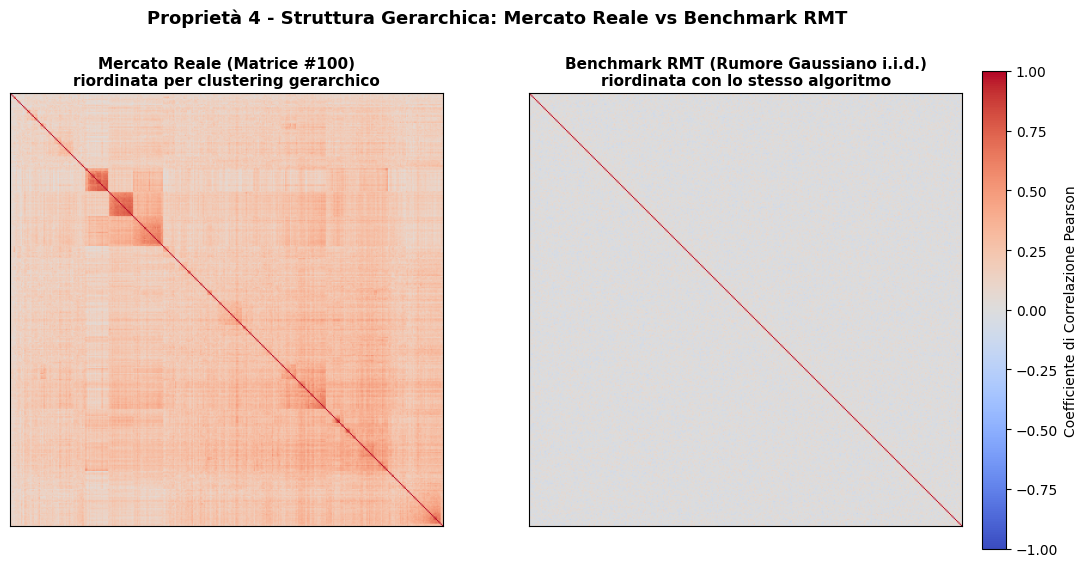

In [8]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform


def hierarchical_order(corr_matrix):
    dist_matrix = build_distance_matrix(corr_matrix)
    condensed = squareform(dist_matrix, checks=False)
    Z = linkage(condensed, method='average')
    return leaves_list(Z)


order_real = hierarchical_order(real_corr)
order_random = hierarchical_order(random_corr)

real_reordered = real_corr[np.ix_(order_real, order_real)]
random_reordered = random_corr[np.ix_(order_random, order_random)]

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2))

im0 = axes[0].imshow(real_reordered, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_title(f'Mercato Reale (Matrice #{SELECTED_CORR_MATRIX})\nriordinata per clustering gerarchico',
                   fontsize=11, fontweight='bold')
axes[0].set_xticks([])
axes[0].set_yticks([])

im1 = axes[1].imshow(random_reordered, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_title('Benchmark RMT (Rumore Gaussiano i.i.d.)\nriordinata con lo stesso algoritmo',
                   fontsize=11, fontweight='bold')
axes[1].set_xticks([])
axes[1].set_yticks([])

cbar = fig.colorbar(im1, ax=axes, fraction=0.035, pad=0.02)
cbar.set_label('Coefficiente di Correlazione Pearson', fontsize=10)

fig.suptitle('Proprietà 4 - Struttura Gerarchica: Mercato Reale vs Benchmark RMT',
             fontsize=13, fontweight='bold', y=0.98)

off_diag_real = real_corr[triu_idx]
off_diag_random = random_corr[triu_idx]
print("--- Struttura Gerarchica ---")
print(f"REALE  -> range correlazioni fuori diagonale: [{off_diag_real.min():.4f}, {off_diag_real.max():.4f}], "
      f"std: {off_diag_real.std():.4f}")
print(f"RANDOM -> range correlazioni fuori diagonale: [{off_diag_random.min():.4f}, {off_diag_random.max():.4f}], "
      f"std: {off_diag_random.std():.4f}")

out_path = FIGURES_FOLDER / 'fig_heatmap_rmt_comparison.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()


### Property 4 (continued): Dendrogram with sector-colored leaves

The heatmap above shows the *reordered* correlation blocks; the dendrogram makes the underlying hierarchy explicit. We draw the same average-linkage tree used for the reordering (so the leaf order matches the heatmap columns exactly), coloring **each asset's terminal vertical line by its GICS sector**.

- **Real market:** adjacent leaves of the same sector fuse at *low* aggregation distance, producing compact same-color blocks — the visual signature of genuine sectoral clusters.
- **Pure-noise benchmark:** with no real co-movement, every asset merges only near the top of the tree (all distances $\approx \sqrt{2}$), and the sector colors are interleaved at random — no color block, i.e. no cluster, forms.

The two panels share the same vertical axis, so the real tree's deep low-distance structure versus the random tree's flat, high-distance "shrub" is directly comparable.


--- Dendrogramma: intervallo delle distanze di fusione ---
REALE  -> merge distance in [0.572, 1.360] (fusioni a bassa distanza = cluster settoriali compatti)
RANDOM -> merge distance in [1.296, 1.415] (tutte le fusioni schiacciate ad alta distanza = nessun cluster)


Saved: ..\tesi\Pictures\capitolo3\fig_dendrogram_rmt_comparison.png


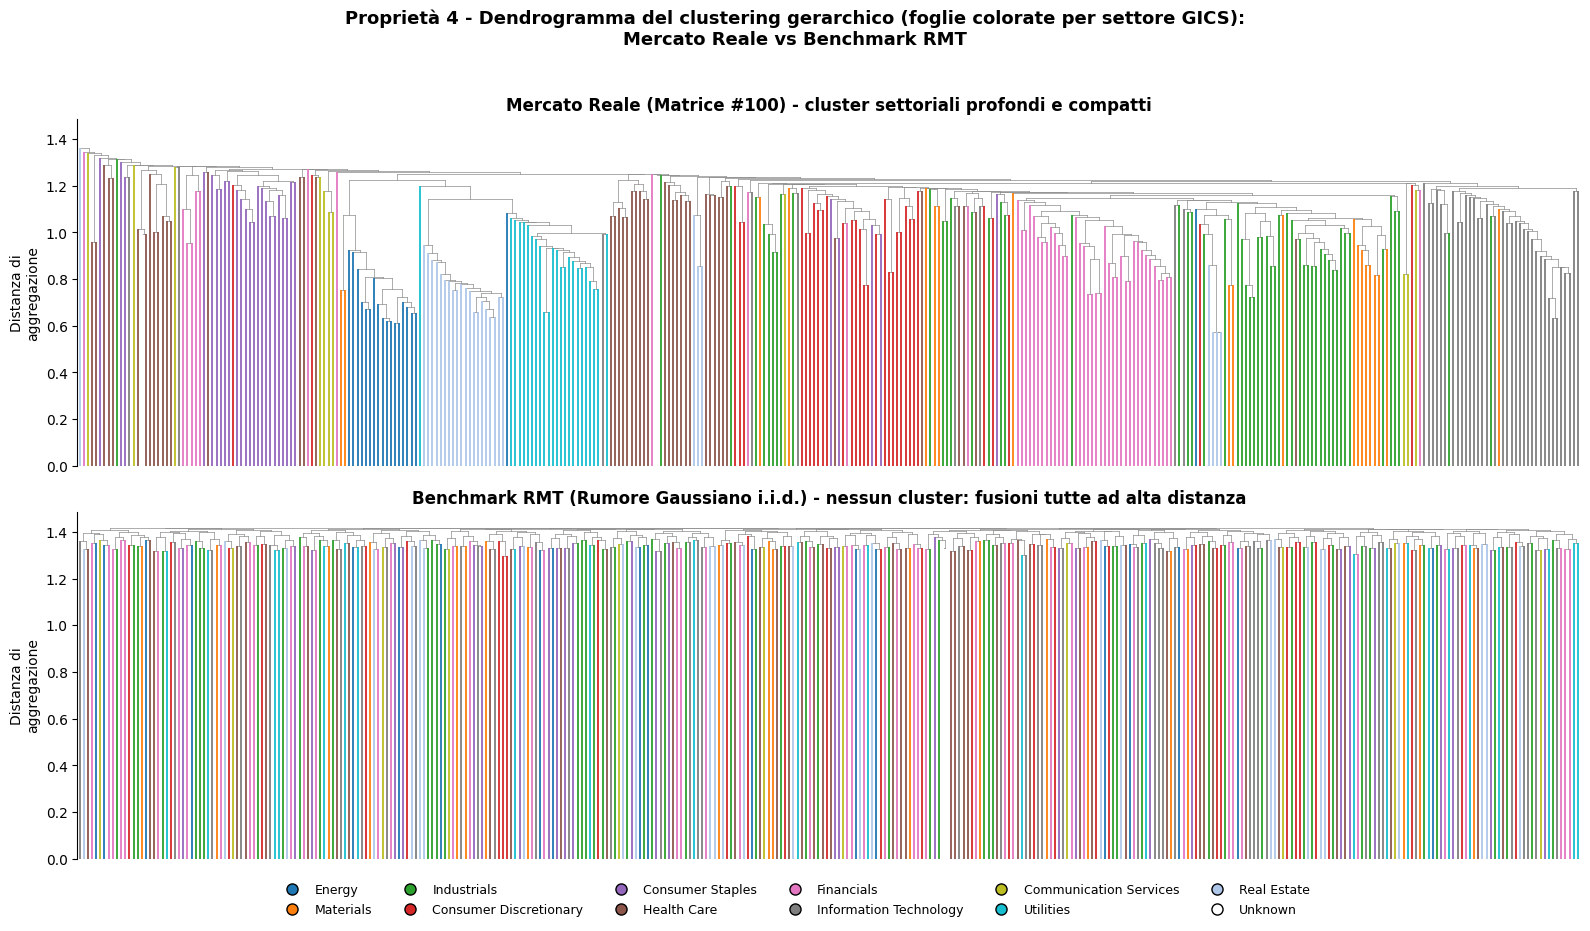

In [9]:
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform

# ----- GICS sector colors (same scheme used for the MST graphs) -----
_gics_df = pd.read_csv(Path('../data/processed/gics_by_ticker.csv'))
_gics_df['ticker'] = _gics_df['ticker'].astype(str).str.upper()
gics_map = dict(zip(_gics_df['ticker'], _gics_df['gics_category']))
sector_order = [
    'Energy', 'Materials', 'Industrials', 'Consumer Discretionary', 'Consumer Staples',
    'Health Care', 'Financials', 'Information Technology', 'Communication Services',
    'Utilities', 'Real Estate', 'Unknown',
]
sector_colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b',
    '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8', '#ffffff',
]
color_map = {s: sector_colors[i] for i, s in enumerate(sector_order)}


def linkage_of(corr_matrix):
    # SAME distance + average linkage as hierarchical_order() -> the dendrogram
    # leaf order equals the heatmap column order (leaves_list == dendrogram leaves).
    return linkage(squareform(build_distance_matrix(corr_matrix), checks=False), method='average')


def plot_colored_dendrogram(ax, Z, title):
    """Draw a dendrogram whose leaf (terminal) vertical lines are colored by the
    GICS sector of the corresponding asset; internal links are neutral gray. A run
    of adjacent same-color leaves is a sectoral cluster."""
    dd = dendrogram(Z, no_plot=True)
    leaves = dd['leaves']

    def leaf_color(x):
        idx = int(round((x - 5.0) / 10.0))          # leaves are placed at x = 5 + 10*idx
        sec = gics_map.get(str(tickers[leaves[idx]]).upper(), 'Unknown')
        return color_map[sec]

    for xs, ys in zip(dd['icoord'], dd['dcoord']):
        x0, x1, x2, x3 = xs
        y0, y1, y2, y3 = ys
        ax.plot([x1, x2], [y1, y2], color='0.55', linewidth=0.5, zorder=1)   # horizontal top link
        # a vertical whose bottom sits at y=0 is a leaf terminal -> color by sector
        if y0 == 0.0:
            ax.plot([x0, x1], [y0, y1], color=leaf_color(x0), linewidth=1.3, zorder=2, solid_capstyle='butt')
        else:
            ax.plot([x0, x1], [y0, y1], color='0.55', linewidth=0.5, zorder=1)
        if y3 == 0.0:
            ax.plot([x2, x3], [y2, y3], color=leaf_color(x3), linewidth=1.3, zorder=2, solid_capstyle='butt')
        else:
            ax.plot([x2, x3], [y2, y3], color='0.55', linewidth=0.5, zorder=1)

    ax.set_xticks([])
    ax.set_xlim(0, 10 * len(leaves))
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Distanza di\naggregazione', fontsize=10)
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)


Z_real = linkage_of(real_corr)
Z_random = linkage_of(random_corr)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(16, 9), sharey=True)
plot_colored_dendrogram(ax0, Z_real,
                        f'Mercato Reale (Matrice #{SELECTED_CORR_MATRIX}) - cluster settoriali profondi e compatti')
plot_colored_dendrogram(ax1, Z_random,
                        'Benchmark RMT (Rumore Gaussiano i.i.d.) - nessun cluster: fusioni tutte ad alta distanza')
ax0.set_ylim(0, 1.05 * max(Z_real[:, 2].max(), Z_random[:, 2].max()))

present_sectors = {gics_map.get(str(tickers[i]).upper(), 'Unknown') for i in range(NUM_ASSETS)}
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=s,
                             markerfacecolor=color_map[s], markeredgecolor='black', markersize=8)
                  for s in sector_order if s in present_sectors]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=6, fontsize=9, frameon=False)

fig.suptitle('Proprietà 4 - Dendrogramma del clustering gerarchico (foglie colorate per settore GICS):\n'
             'Mercato Reale vs Benchmark RMT', fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])

# consistency check with the heatmap ordering
assert np.array_equal(leaves_list(Z_real), dendrogram(Z_real, no_plot=True)['leaves'])
print("--- Dendrogramma: intervallo delle distanze di fusione ---")
print(f"REALE  -> merge distance in [{Z_real[:, 2].min():.3f}, {Z_real[:, 2].max():.3f}] "
      f"(fusioni a bassa distanza = cluster settoriali compatti)")
print(f"RANDOM -> merge distance in [{Z_random[:, 2].min():.3f}, {Z_random[:, 2].max():.3f}] "
      f"(tutte le fusioni schiacciate ad alta distanza = nessun cluster)")

out_path = FIGURES_FOLDER / 'fig_dendrogram_rmt_comparison.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()

## Section 6: Property 5 - Minimum Spanning Tree and the Scale-Free Property

**Real markets:** the MST degree distribution follows a power law $P(k) \propto k^{-\gamma}$ (roughly linear in log-log scale), dominated by a handful of super-connected hub nodes.

**Pure-noise benchmark:** with no preferential attachment mechanism, the MST built from random distances produces a narrow, hub-less degree distribution (most nodes have degree 1-3, no node reaches the high degrees seen in real hubs) - and it is **not** linear in log-log scale.


--- MST Degree Distribution ---
REALE  -> grado max: 14, grado medio: 1.994, std: 1.795
RANDOM -> grado max: 6, grado medio: 1.994, std: 1.100
FIT power-law (Mercato Reale) -> pendenza = -2.207, R^2 = 0.979

Distribuzione gradi REALE: {1: 208, 2: 78, 3: 29, 4: 20, 5: 9, 6: 6, 7: 3, 8: 4, 10: 2, 11: 1, 12: 1, 14: 1}
Distribuzione gradi RANDOM: {1: 149, 2: 119, 3: 57, 4: 23, 5: 12, 6: 2}


Saved: ..\tesi\Pictures\capitolo3\fig_mst_degree_rmt_comparison.png


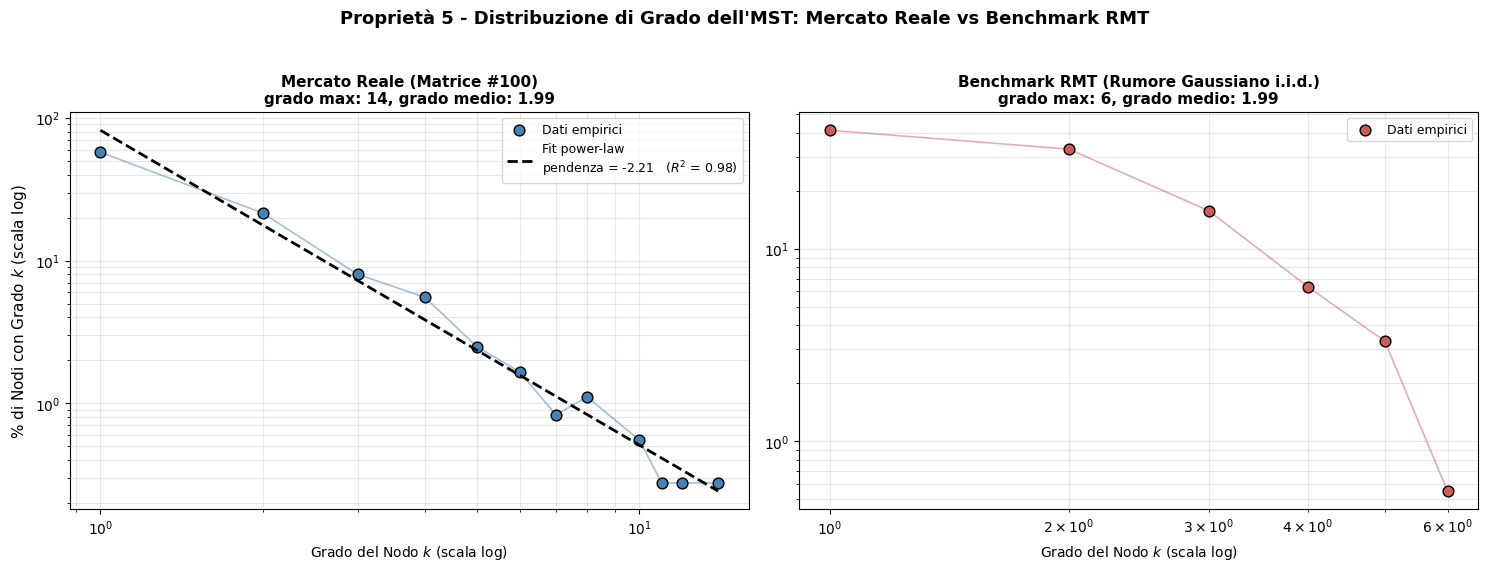

In [10]:
import networkx as nx


def mst_degrees(corr_matrix):
    dist_matrix = build_distance_matrix(corr_matrix)
    G = nx.from_numpy_array(dist_matrix)
    mst = nx.minimum_spanning_tree(G, weight='weight')
    degrees = np.array([d for _, d in mst.degree()])
    return mst, degrees


mst_real, degrees_real = mst_degrees(real_corr)
mst_random, degrees_random = mst_degrees(random_corr)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

fit_slope, fit_r2 = None, None
for ax, degrees, title, color, add_fit in [
    (axes[0], degrees_real, f'Mercato Reale (Matrice #{SELECTED_CORR_MATRIX})', 'steelblue', True),
    (axes[1], degrees_random, 'Benchmark RMT (Rumore Gaussiano i.i.d.)', 'indianred', False),
]:
    unique_deg, counts = np.unique(degrees, return_counts=True)
    pct = 100.0 * counts / NUM_ASSETS
    ax.scatter(unique_deg, pct, color=color, edgecolor='black', s=60, zorder=3, label='Dati empirici')
    ax.plot(unique_deg, pct, color=color, alpha=0.5, linewidth=1.2, zorder=2)

    # Power-law fit in log-log space (P(k) ~ k^slope): the scale-free signature
    # is a straight line whose slope is the estimated exponent. Fitted only on the
    # real market panel, where the distribution spans enough distinct degrees to be
    # meaningful (the pure-noise benchmark is concave and NOT a power law by design).
    if add_fit and len(unique_deg) >= 3:
        log_k = np.log10(unique_deg.astype(float))
        log_p = np.log10(pct)
        fit_slope, intercept = np.polyfit(log_k, log_p, 1)
        p_pred = fit_slope * log_k + intercept
        ss_res = np.sum((log_p - p_pred) ** 2)
        ss_tot = np.sum((log_p - log_p.mean()) ** 2)
        fit_r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float('nan')
        k_line = np.logspace(np.log10(unique_deg.min()), np.log10(unique_deg.max()), 100)
        p_line = 10.0 ** intercept * k_line ** fit_slope
        ax.plot(k_line, p_line, color='black', linestyle='--', linewidth=2.0, zorder=4,
                label=f'Fit power-law\npendenza = {fit_slope:.2f}   ($R^2$ = {fit_r2:.2f})')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'{title}\ngrado max: {degrees.max()}, grado medio: {degrees.mean():.2f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Grado del Nodo $k$ (scala log)', fontsize=10)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=9, loc='upper right')

axes[0].set_ylabel('% di Nodi con Grado $k$ (scala log)', fontsize=11)
fig.suptitle("Proprietà 5 - Distribuzione di Grado dell'MST: Mercato Reale vs Benchmark RMT",
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()

print("--- MST Degree Distribution ---")
print(f"REALE  -> grado max: {degrees_real.max()}, grado medio: {degrees_real.mean():.3f}, "
      f"std: {degrees_real.std():.3f}")
print(f"RANDOM -> grado max: {degrees_random.max()}, grado medio: {degrees_random.mean():.3f}, "
      f"std: {degrees_random.std():.3f}")
if fit_slope is not None:
    print(f"FIT power-law (Mercato Reale) -> pendenza = {fit_slope:.3f}, R^2 = {fit_r2:.3f}")
print()
print("Distribuzione gradi REALE:", dict(zip(*np.unique(degrees_real, return_counts=True))))
print("Distribuzione gradi RANDOM:", dict(zip(*np.unique(degrees_random, return_counts=True))))

out_path = FIGURES_FOLDER / 'fig_mst_degree_rmt_comparison.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()

Saved: ..\tesi\Pictures\capitolo3\fig_mst_graph_rmt_comparison.png


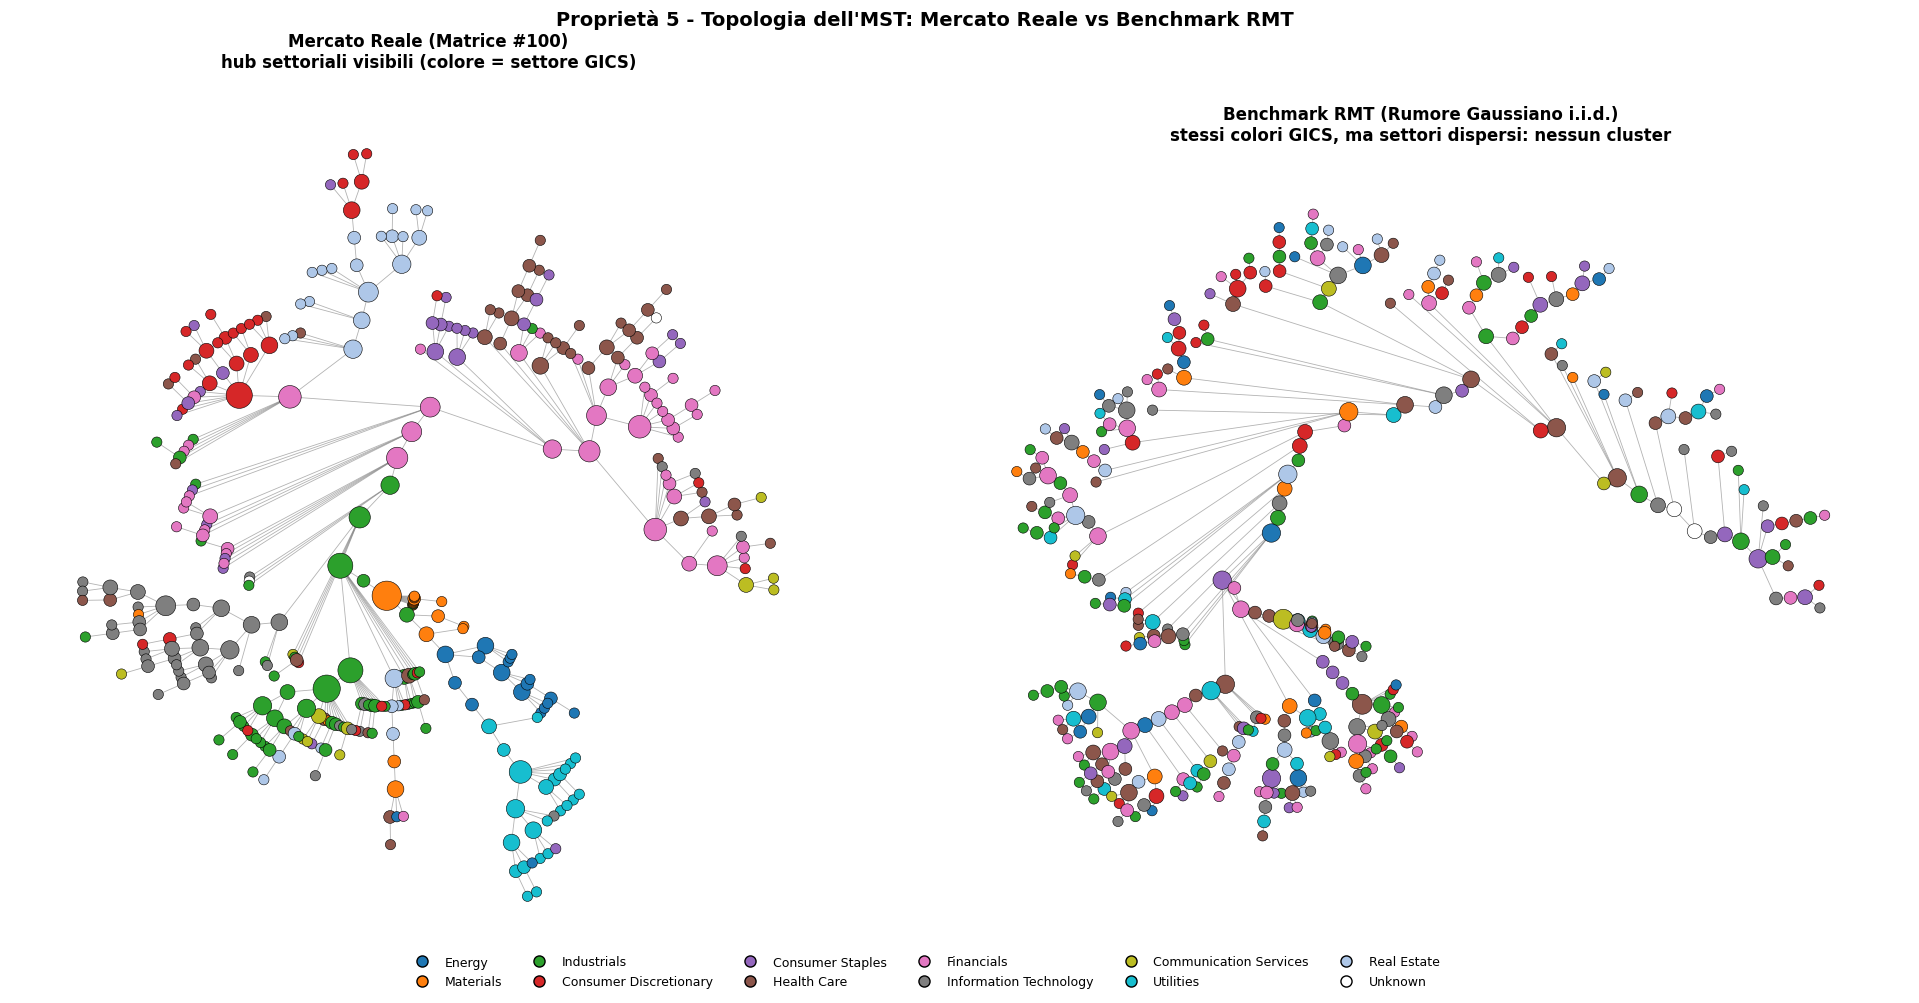

In [11]:
import collections


def radial_tree_layout(tree, root=None, radial_gap=1.0):
    """Crossing-free radial layout for a tree (an MST is always a tree).

    Each node sits on a circle of radius depth*radial_gap; every subtree is
    confined to its own angular wedge, whose width is proportional to the number
    of leaves it contains. Because sibling subtrees occupy disjoint wedges, edges
    belonging to different branches can never cross -- unlike a force-directed
    (spring) layout, which collapses a 362-node tree into an unreadable hairball
    with heavy node/edge overlap.
    """
    if root is None:
        root = max(tree.degree, key=lambda kv: kv[1])[0]   # highest-degree node = main hub
    parent = {root: None}
    children = collections.defaultdict(list)
    depth = {root: 0}
    order = [root]
    dq = collections.deque([root])
    while dq:
        u = dq.popleft()
        for v in tree.neighbors(u):
            if v not in parent:
                parent[v] = u
                children[u].append(v)
                depth[v] = depth[u] + 1
                order.append(v)
                dq.append(v)
    # leaf count of each subtree -> angular weight
    weight = {}
    for n in reversed(order):
        weight[n] = 1 if not children[n] else sum(weight[c] for c in children[n])
    # assign angular wedges top-down and place nodes at the wedge midpoint
    wedge = {root: (0.0, 2.0 * np.pi)}
    pos = {}
    for n in order:
        a0, a1 = wedge[n]
        theta = 0.5 * (a0 + a1)
        r = depth[n] * radial_gap
        pos[n] = (r * np.cos(theta), r * np.sin(theta))
        total = sum(weight[c] for c in children[n]) or 1
        acc = a0
        for c in sorted(children[n], key=lambda x: -weight[x]):
            span = (a1 - a0) * weight[c] / total
            wedge[c] = (acc, acc + span)
            acc += span
    return pos


# ===== MST graph visualization: Real vs Random, both colored by GICS sector =====
gics_path = Path('../data/processed/gics_by_ticker.csv')
gics_df = pd.read_csv(gics_path)
gics_df['ticker'] = gics_df['ticker'].astype(str).str.upper()
gics_map = dict(zip(gics_df['ticker'], gics_df['gics_category']))

sector_order = [
    'Energy', 'Materials', 'Industrials', 'Consumer Discretionary', 'Consumer Staples',
    'Health Care', 'Financials', 'Information Technology', 'Communication Services',
    'Utilities', 'Real Estate', 'Unknown',
]
sector_colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b',
    '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8', '#ffffff',
]
color_map = {sector: sector_colors[i] for i, sector in enumerate(sector_order)}

# ----- Real MST: nodes carry ticker labels, colored by their GICS sector -----
mst_real_labeled = nx.relabel_nodes(mst_real, {i: str(tickers[i]) for i in range(len(tickers))})
node_names_real = list(mst_real_labeled.nodes())
node_sectors_real = [gics_map.get(str(n).upper(), 'Unknown') for n in node_names_real]
node_colors_real = [color_map[s] for s in node_sectors_real]
degree_dict_real = dict(mst_real_labeled.degree())
node_sizes_real = [25 + 30 * degree_dict_real[n] for n in node_names_real]

# ----- Random MST: same asset identity (node i <-> tickers[i]), same GICS colors.
# Applying the identical sector coloring makes the key point visually explicit:
# the sectors are scattered at random and NO cluster forms -- the very absence of
# structure the benchmark is meant to demonstrate. -----
node_names_random = list(mst_random.nodes())
node_sectors_random = [gics_map.get(str(tickers[i]).upper(), 'Unknown') for i in node_names_random]
node_colors_random = [color_map[s] for s in node_sectors_random]
degree_dict_random = dict(mst_random.degree())
node_sizes_random = [25 + 30 * degree_dict_random[i] for i in node_names_random]

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Radial tree layout -> no edge crossings, hubs clearly separated
pos_real = radial_tree_layout(mst_real_labeled)
nx.draw_networkx_edges(mst_real_labeled, pos_real, ax=axes[0], alpha=0.6, width=0.6, edge_color='gray')
nx.draw_networkx_nodes(mst_real_labeled, pos_real, ax=axes[0], node_color=node_colors_real,
                        node_size=node_sizes_real, edgecolors='black', linewidths=0.4)
axes[0].set_title(f'Mercato Reale (Matrice #{SELECTED_CORR_MATRIX})\nhub settoriali visibili (colore = settore GICS)',
                   fontsize=12, fontweight='bold')
axes[0].axis('off')
axes[0].set_aspect('equal')

pos_random = radial_tree_layout(mst_random)
nx.draw_networkx_edges(mst_random, pos_random, ax=axes[1], alpha=0.6, width=0.6, edge_color='gray')
nx.draw_networkx_nodes(mst_random, pos_random, ax=axes[1], node_color=node_colors_random,
                        node_size=node_sizes_random, edgecolors='black', linewidths=0.4)
axes[1].set_title('Benchmark RMT (Rumore Gaussiano i.i.d.)\nstessi colori GICS, ma settori dispersi: nessun cluster',
                   fontsize=12, fontweight='bold')
axes[1].axis('off')
axes[1].set_aspect('equal')

# Shared sector legend: both panels use the same GICS color scheme
present_sectors = set(node_sectors_real) | set(node_sectors_random)
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=s,
                              markerfacecolor=color_map[s], markeredgecolor='black', markersize=8)
                   for s in sector_order if s in present_sectors]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.01),
           ncol=6, fontsize=9, frameon=False)

fig.suptitle("Proprietà 5 - Topologia dell'MST: Mercato Reale vs Benchmark RMT", fontsize=14, fontweight='bold')
plt.tight_layout()

out_path = FIGURES_FOLDER / 'fig_mst_graph_rmt_comparison.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()

## Section 7: Summary

The five panels above reproduce, figure by figure, the qualitative failure summarized in Table `tab:comparazione_rmt`: a purely random correlation matrix built from i.i.d. Gaussian noise with the same dimensionality ($N=362$, $T=724$) as the real market matrix systematically fails every one of the five stylized facts that characterize real financial markets. This provides the visual evidence referenced in Section 3.7 of the thesis.
